In [1]:
import sys
print(sys.executable)

c:\Users\shreyas\anaconda3\envs\liver\python.exe


In [2]:
import torch

print(torch.__version__)
print("CUDA:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
CUDA: True
NVIDIA GeForce RTX 4070 Laptop GPU


In [6]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4070 Laptop GPU


In [6]:
import os

folder = r"C:\Users\shreyas\OneDrive\Desktop\LITS17"

for f in os.listdir(folder)[:10]:
    print(repr(f))

'segmentation-0.nii'
'segmentation-0.nii.zip'
'segmentation-1.nii.zip'
'segmentation-10.nii.zip'
'segmentation-100.nii.zip'
'segmentation-101.nii.zip'
'segmentation-102.nii.zip'
'segmentation-103.nii.zip'
'segmentation-104.nii.zip'
'segmentation-105.nii.zip'


In [7]:
import os
import zipfile

folder = r"C:\Users\shreyas\OneDrive\Desktop\LITS17"

zip_files = [f for f in os.listdir(folder) if f.endswith(".zip")]

for zip_name in zip_files:
    zip_path = os.path.join(folder, zip_name)

    try:
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(folder)

        os.remove(zip_path)

        print(f"✅ Extracted and deleted: {zip_name}")

    except Exception as e:
        print(f"❌ Failed: {zip_name}")
        print(e)

print("🎉 Finished!")

❌ Failed: segmentation-0.nii.zip
[Errno 13] Permission denied: 'C:\\Users\\shreyas\\OneDrive\\Desktop\\LITS17\\segmentation-0.nii'
✅ Extracted and deleted: segmentation-1.nii.zip
✅ Extracted and deleted: segmentation-10.nii.zip
✅ Extracted and deleted: segmentation-100.nii.zip
✅ Extracted and deleted: segmentation-101.nii.zip
✅ Extracted and deleted: segmentation-102.nii.zip
✅ Extracted and deleted: segmentation-103.nii.zip
✅ Extracted and deleted: segmentation-104.nii.zip
✅ Extracted and deleted: segmentation-105.nii.zip
✅ Extracted and deleted: segmentation-106.nii.zip
✅ Extracted and deleted: segmentation-107.nii.zip
✅ Extracted and deleted: segmentation-108.nii.zip
✅ Extracted and deleted: segmentation-109.nii.zip
✅ Extracted and deleted: segmentation-11.nii.zip
✅ Extracted and deleted: segmentation-110.nii.zip
✅ Extracted and deleted: segmentation-111.nii.zip
✅ Extracted and deleted: segmentation-112.nii.zip
✅ Extracted and deleted: segmentation-113.nii.zip
✅ Extracted and deleted

In [9]:
import sys

print(sys.executable)

c:\Users\shreyas\anaconda3\envs\liver\python.exe


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import SimpleITK as sitk
import nibabel as nib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))
    print("CUDA Version    :", torch.version.cuda)
else:
    print("Running on CPU")

print("=" * 60)

PyTorch Version : 2.6.0+cu124
CUDA Available  : True
GPU Name        : NVIDIA GeForce RTX 4070 Laptop GPU
CUDA Version    : 12.4


In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

LITS_DIR = DATA_DIR / "LiTS17"
MSD_DIR = DATA_DIR / "Task03_Liver"
TCGA_DIR = DATA_DIR / "tcga_lihc"

PROCESSED_DIR = PROJECT_ROOT / "datasets" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Data Folder  :", DATA_DIR)
print("Processed    :", PROCESSED_DIR)

Project Root : c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M
Data Folder  : c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M\data
Processed    : c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M\datasets\processed


In [4]:
datasets = {
    "LiTS17": LITS_DIR,
    "MSD Task03": MSD_DIR,
    "TCGA-LIHC": TCGA_DIR,
}

print("=" * 60)

for name, folder in datasets.items():
    if folder.exists():
        print(f"✅ {name}: Found")
    else:
        print(f"❌ {name}: Missing")

print("=" * 60)

✅ LiTS17: Found
✅ MSD Task03: Found
✅ TCGA-LIHC: Found


In [5]:
print("=" * 60)

# LiTS
lits_files = list(LITS_DIR.glob("*.nii"))
print(f"LiTS17 NIfTI files      : {len(lits_files)}")

# MSD
msd_images = list((MSD_DIR / "imagesTr").glob("*.nii.gz"))
msd_labels = list((MSD_DIR / "labelsTr").glob("*.nii.gz"))

print(f"MSD Training Images     : {len(msd_images)}")
print(f"MSD Training Labels     : {len(msd_labels)}")

# TCGA
patients = [p for p in TCGA_DIR.iterdir() if p.is_dir()]
print(f"TCGA Patients           : {len(patients)}")

print("=" * 60)

LiTS17 NIfTI files      : 261
MSD Training Images     : 262
MSD Training Labels     : 262
TCGA Patients           : 97


In [6]:
# Load one LiTS image

lits_sample = sorted(LITS_DIR.glob("volume-*.nii"))[0]

image = sitk.ReadImage(str(lits_sample))
volume = sitk.GetArrayFromImage(image)

print("="*60)
print("LiTS Sample")
print("="*60)

print("Filename :", lits_sample.name)
print("Shape    :", volume.shape)
print("Spacing  :", image.GetSpacing())
print("Origin   :", image.GetOrigin())

print("Min HU   :", volume.min())
print("Max HU   :", volume.max())

LiTS Sample
Filename : volume-0.nii
Shape    : (75, 512, 512)
Spacing  : (0.703125, 0.703125, 5.0)
Origin   : (-172.89999389648438, 179.296875, -368.0)
Min HU   : -3024.0
Max HU   : 1410.0


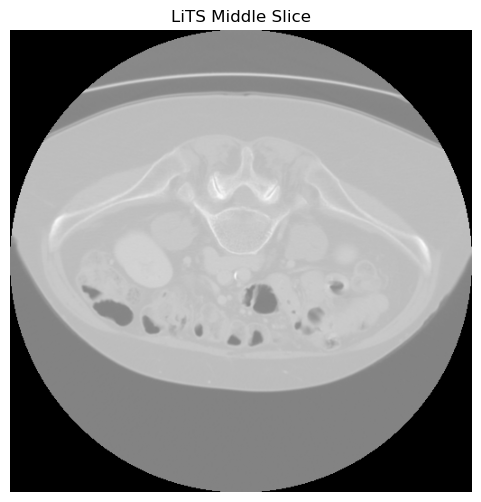

In [7]:
mid = volume.shape[0] // 2

plt.figure(figsize=(6,6))
plt.imshow(volume[mid], cmap="gray")
plt.title("LiTS Middle Slice")
plt.axis("off")
plt.show()

In [16]:
msd_sample = sorted((MSD_DIR / "imagesTr").glob("*.nii.gz"))[0]

image = sitk.ReadImage(str(msd_sample))
volume = sitk.GetArrayFromImage(image)

print("=" * 60)
print("MSD Sample")
print("=" * 60)

print("Filename :", msd_sample.name)
print("Shape    :", volume.shape)
print("Spacing  :", image.GetSpacing())
print("Origin   :", image.GetOrigin())

print("Min HU   :", volume.min())
print("Max HU   :", volume.max())

MSD Sample
Filename : liver_0.nii.gz
Shape    : (75, 512, 512)
Spacing  : (0.703125, 0.703125, 5.0)
Origin   : (186.39688110351562, 179.296875, -368.0)
Min HU   : -1024.0
Max HU   : 1410.0


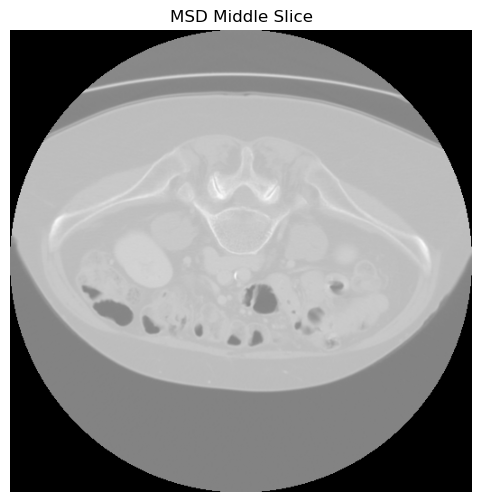

In [9]:
mid = volume.shape[0] // 2

plt.figure(figsize=(6,6))
plt.imshow(volume[mid], cmap="gray")
plt.title("MSD Middle Slice")
plt.axis("off")
plt.show()

In [10]:
patient = sorted(TCGA_DIR.iterdir())[0]

print(patient.name)

TCGA-BC-4073


In [11]:
reader = sitk.ImageSeriesReader()

series_IDs = reader.GetGDCMSeriesIDs(str(patient))

print(series_IDs)

()


In [17]:
patient = sorted(TCGA_DIR.iterdir())[0]

print("Patient folder:")
print(patient)

Patient folder:
c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M\data\tcga_lihc\TCGA-BC-4073


In [18]:
print("Contents of patient folder:\n")

for item in patient.iterdir():
    print(item.name)

Contents of patient folder:

36417
52593
85289


In [19]:
series_folder = sorted([f for f in patient.iterdir() if f.is_dir()])[0]

print("Series folder:", series_folder)

print("\nFirst 10 files:")

for f in list(series_folder.iterdir())[:10]:
    print(f.name)

Series folder: c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M\data\tcga_lihc\TCGA-BC-4073\36417

First 10 files:
06111
10506
19488
24967
33940
39326
44283
47394
57910
77239


In [20]:
study_folder = sorted([f for f in patient.iterdir() if f.is_dir()])[0]

print("Study folder:", study_folder)

print("\nSubfolders:")

for f in study_folder.iterdir():
    print(f.name)

Study folder: c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M\data\tcga_lihc\TCGA-BC-4073\36417

Subfolders:
06111
10506
19488
24967
33940
39326
44283
47394
57910
77239
77999
89093
90470


In [21]:
series_folder = sorted([f for f in study_folder.iterdir() if f.is_dir()])[0]

print("Series folder:", series_folder)

print("\nFirst 10 entries:")

for f in list(series_folder.iterdir())[:10]:
    print(f.name)

Series folder: c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M\data\tcga_lihc\TCGA-BC-4073\36417\06111

First 10 entries:
09af6ce7-b1b2-43b3-8794-8a2db5f12621.dcm
0d6a3bc0-3ecc-45b4-a1e3-7a0e6ab0acdc.dcm
0d79d6c6-ee9f-4462-87a9-c228aa3677e8.dcm
18025f24-3651-4027-9d1c-6fddb8a66446.dcm
228f7d55-b6d0-4b68-90a7-c2411663553f.dcm
2885b60b-0c23-4815-99b6-fd48cbe61e27.dcm
2b424305-97fa-45bf-9327-3d34c104afe3.dcm
3d60f3b2-3879-45ec-ab1a-26ace6c318ff.dcm
3d6b873d-807e-4fd2-a8a6-65aec511b62a.dcm
3f8e8af8-bcac-4257-938c-ca2e0b29512b.dcm


In [22]:

patient = sorted([p for p in TCGA_DIR.iterdir() if p.is_dir()])[0]

study = sorted([s for s in patient.iterdir() if s.is_dir()])[0]

series = sorted([s for s in study.iterdir() if s.is_dir()])[0]

print("Patient :", patient.name)
print("Study   :", study.name)
print("Series  :", series.name)

reader = sitk.ImageSeriesReader()

dicom_names = reader.GetGDCMSeriesFileNames(str(series))

reader.SetFileNames(dicom_names)

image = reader.Execute()

volume = sitk.GetArrayFromImage(image)

print("=" * 60)
print("TCGA Sample")
print("=" * 60)

print("Shape      :", volume.shape)
print("Spacing    :", image.GetSpacing())
print("Origin     :", image.GetOrigin())
print("Direction  :", image.GetDirection())

print("Min HU     :", volume.min())
print("Max HU     :", volume.max())

Patient : TCGA-BC-4073
Study   : 36417
Series  : 06111
TCGA Sample
Shape      : (35, 208, 256)
Spacing    : (1.484375, 1.484375, 7.260000116684853)
Origin     : (-199.55852985382, -181.38074684143, -87.766609191895)
Direction  : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Min HU     : 0
Max HU     : 277


In [24]:

def load_tcga_patient(patient_folder):
    """
    Load the first CT series for a TCGA patient.

    Parameters
    ----------
    patient_folder : pathlib.Path

    Returns
    -------
    image : SimpleITK Image
    volume : numpy.ndarray
    """

    patient_folder = Path(patient_folder)

    # First study
    study = sorted([f for f in patient_folder.iterdir() if f.is_dir()])[0]

    # First series
    series = sorted([f for f in study.iterdir() if f.is_dir()])[0]

    reader = sitk.ImageSeriesReader()

    dicom_names = reader.GetGDCMSeriesFileNames(str(series))

    reader.SetFileNames(dicom_names)

    image = reader.Execute()

    volume = sitk.GetArrayFromImage(image)

    return image, volume

In [25]:
patient = sorted([p for p in TCGA_DIR.iterdir() if p.is_dir()])[0]

image, volume = load_tcga_patient(patient)

print("Patient :", patient.name)
print("Shape   :", volume.shape)
print("Spacing :", image.GetSpacing())
print("HU Min  :", volume.min())
print("HU Max  :", volume.max())

Patient : TCGA-BC-4073
Shape   : (35, 208, 256)
Spacing : (1.484375, 1.484375, 7.260000116684853)
HU Min  : 0
HU Max  : 277


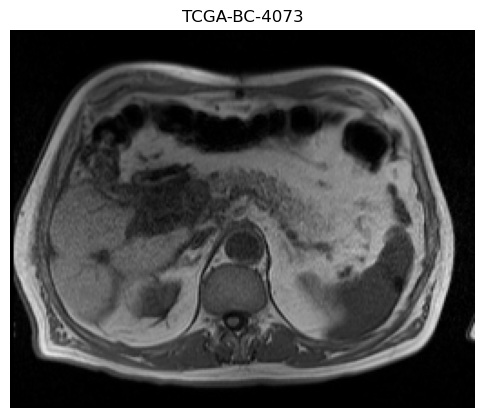

In [26]:
mid = volume.shape[0] // 2

plt.figure(figsize=(6,6))
plt.imshow(volume[mid], cmap="gray")
plt.title(patient.name)
plt.axis("off")
plt.show()